In [30]:
import seaborn as sns
import  matplotlib.pyplot as plt 
import pandas as pd

On charge les données + on ajoute une variable qui comptabilise la proportion de temps par jour, pour chaque chaîne et thématique

In [ ]:
from load_data.donnees_chargement import load_sujet_tele

sujet_tele = load_sujet_tele()
#on calcule le temps total du JT de chaque jour pour chaque chaîne:
sujet_tele['Temps_total_JT'] = sujet_tele.groupby(['Date','Chaîne'])['Duree_sec'].transform(sum)
#on créer une colonne "prop" qui contient la proportion de temps dans l'émission dédiée à un type de sujet 
sujet_tele['Prop']=sujet_tele['Duree_sec']/sujet_tele['Temps_total_JT']
sujet_tele.head(20)

b'02/01/2000;France 3;'


/tmp/ipykernel_48394/2089051497.py:5: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  sujet_tele['Temps_total_JT'] = sujet_tele.groupby(['Date','Chaîne'])['Duree_sec'].transform(sum)


,Date,Chaîne,Thématique,Nb_sujets,Duree_sec,Temps_total_JT,Prop
0,2000-01-02,France 3,Catastrophes,2,235,1254,0.187400
1,2000-01-02,France 3,Culture-loisirs,1,138,1254,0.110048
2,2000-01-02,France 3,Environnement,3,306,1254,0.244019
3,2000-01-02,France 3,International,2,241,1254,0.192185
4,2000-01-02,France 3,Société,2,160,1254,0.127592
5,2000-01-02,France 3,Sport,2,174,1254,0.138756
6,2000-01-03,France 3,Catastrophes,3,329,1190,0.276471
7,2000-01-03,France 3,Culture-loisirs,1,38,1190,0.031933
8,2000-01-03,France 3,Economie,2,191,1190,0.160504
9,2000-01-03,France 3,Education,2,224,1190,0.188235


In [41]:
#ensemble des chaînes de sujet_tele
sujet_tele['Chaîne'].unique()

array(['France 3', 'Arte', 'M6', 'France 2', 'TF1'], dtype=object)

On 

In [42]:
#on filtre les données pour chaque chaîne : 
sujet_tele_M6 = sujet_tele[sujet_tele['Chaîne']=='M6']
sujet_tele_FR3 = sujet_tele[sujet_tele['Chaîne']=='France 3']
sujet_tele_Arte = sujet_tele[sujet_tele['Chaîne']=='Arte']
sujet_tele_FR2 = sujet_tele[sujet_tele['Chaîne']=='France 2']
sujet_tele_TF1 = sujet_tele[sujet_tele['Chaîne']=='TF1']

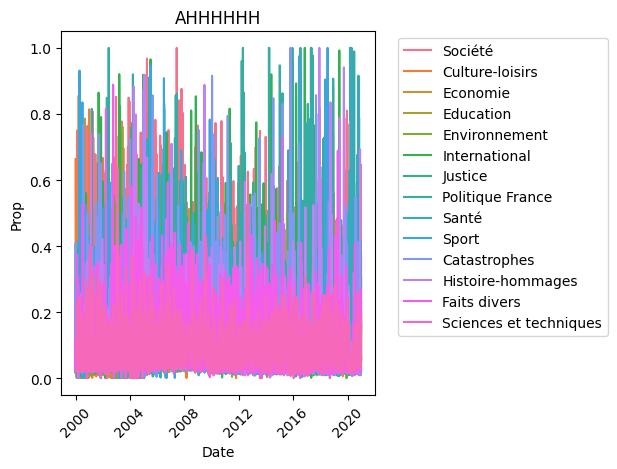

In [43]:
#on représente avec seaborn : M6
sns.lineplot(data=sujet_tele_M6, x='Date', y='Prop', hue='Thématique')
plt.title('AHHHHHH')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# peu lisible : on va lisser prendre la proportion moyenne par mois 

In [52]:
# on va regrouper les proportions par mois pour plus de lisibilité

sujet_tele_M6_month = sujet_tele_M6.groupby([sujet_tele_M6['Date'].dt.to_period('M'), 'Thématique'])['Prop'].mean().reset_index()
sujet_tele_M6_month['Date'] = sujet_tele_M6_month['Date'].dt.to_timestamp()
sujet_tele_M6_month


,Date,Thématique,Prop
0,2000-01-01,Catastrophes,0.171436
1,2000-01-01,Culture-loisirs,0.166632
2,2000-01-01,Economie,0.136145
3,2000-01-01,Education,0.197997
4,2000-01-01,Environnement,0.140472
...,...,...,...
3498,2020-12-01,Politique France,0.087086
3499,2020-12-01,Santé,0.244334
3500,2020-12-01,Sciences et techniques,0.092624
3501,2020-12-01,Société,0.238170


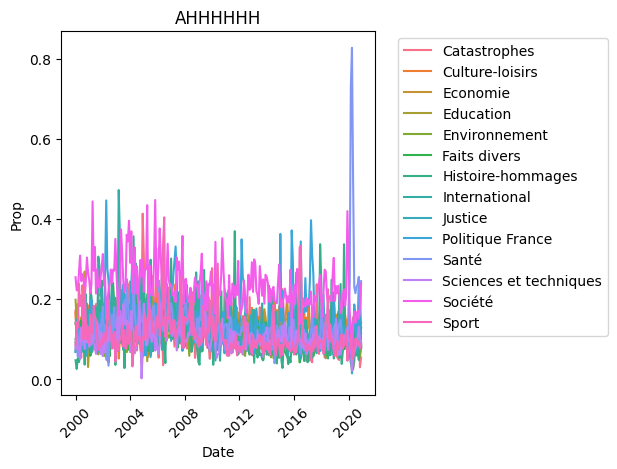

In [54]:
sns.lineplot(data=sujet_tele_M6_month, x='Date', y='Prop', hue='Thématique')
plt.title('AHHHHHH')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

au lieu d'avoir un plot par chaîne on pourrait avoir un plot par thématique où on compare les chaînes.

Ci-dessous on fait une fonction pour adapter la table sujet_tele à l'échelle de temps : par année ou par mois.
Exemple: par mois = renvoyer une table avec pour chaque chaîne, chaque thématique et selon le mois, le temps cumulé par thématique et le temps total cumulé par chaîne dans le mois.

In [60]:
def sujet_convert(indic, table, Date = 'Date', Thématique = 'Thématique', Duree_sec = 'Duree_sec', Chaine = 'Chaîne'):
    if indic not in ("Y", "M"):
        raise ValueError("Y pour year ou M pour Month à mettre en entrée")
    table_convert= table.groupby([table[Date].dt.to_period(indic), Chaine, Thématique])[Duree_sec].sum().reset_index()
    table_convert.rename(columns={Duree_sec: 'Temps cumul'}, inplace=True)
    table_convert_mean = table.groupby([table[Date].dt.to_period(indic), Chaine, Thématique])[Duree_sec].mean().reset_index()
    table_convert_mean.rename(columns={Duree_sec: 'Temps moyen'}, inplace=True)
    table_convert['Temps moyen'] = table_convert_mean['Temps moyen']
    return table_convert

In [62]:
sujet_tele_Y = sujet_convert("M", table = sujet_tele)
sujet_tele_Y

,Date,Chaîne,Thématique,Temps cumul,Temps moyen
0,2000-01,Arte,Catastrophes,1222,135.777778
1,2000-01,Arte,Culture-loisirs,4654,193.916667
2,2000-01,Arte,Economie,2357,168.357143
3,2000-01,Arte,Education,46,23.000000
4,2000-01,Arte,Environnement,2186,198.727273
...,...,...,...,...,...
17283,2020-12,TF1,Politique France,2567,183.357143
17284,2020-12,TF1,Santé,23892,770.709677
17285,2020-12,TF1,Sciences et techniques,3016,274.181818
17286,2020-12,TF1,Société,11214,386.689655
